In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
'''图片数据集载入'''
import torch
import torchvision
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
transform1 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
test_path ='/content/drive/MyDrive/yoga/yoga_pose_solo_evaluated_splited/test/tree'
testset1 = torchvision.datasets.ImageFolder(root=test_path,transform=transform1)
print(len(testset1))
testloader1 = torch.utils.data.DataLoader(
    testset1, batch_size=64, shuffle=False)

63


In [3]:
'''骨架坐标点数据集载入'''
import pandas as pd
import numpy as np
df = pd.read_excel("/content/drive/MyDrive/yoga/landmarks/tree_test_landmarks.xlsx")
#df = df[df['体式']=='downdog']
df.loc[df['标准/不标准']=='nonstandard', '是否标准编号'] = 0
df.loc[df['标准/不标准']=='standard', '是否标准编号'] = 1
df.drop(["编号", '体式', '标准/不标准'],axis=1, inplace=True)
dataset_test = df.values
dataset_test = np.array(dataset_test)
X_test = dataset_test[:,:-1].astype(float)
Y_test = dataset_test[:,-1:].astype(int).squeeze(-1)
X_test, Y_test = torch.Tensor(X_test),torch.LongTensor(Y_test)
#print(X_test, Y_test)
testset2 = torch.utils.data.TensorDataset(X_test,Y_test)
print(len(testset2))
testloader2 = torch.utils.data.DataLoader(
    testset2, batch_size=64, shuffle=False)

63


In [4]:
import torch.nn as nn
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.all = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Dropout(p=0.5),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )
    def forward(self, x):
        out = self.all(x)
        return out

In [5]:
def test(net1, net2, we):
    correct = 0
    total = 0
    total_l = [0,0]
    correct_l = [0,0]
    pred_y = torch.tensor([]).to(device)
    Y_test = torch.tensor([]).to(device)
    it_testloader2 = iter(testloader2)
    with torch.no_grad():
        for data in testloader1:
            images1, labels = data
            images1, labels = images1.to(device), labels.to(device)
            inputs2, labelss = next(it_testloader2)
            inputs2, labelss = inputs2.to(device), labelss.to(device)
            outputs1 = net1(images1)
            outputs2 = net2(inputs2)
            outputs = outputs1 * we + outputs2
            _,predicted = torch.max(outputs.data, 1)
            pred_y = torch.cat([pred_y,predicted])
            Y_test = torch.cat([Y_test,labels])
            total += labels.size(0)
            correct += (predicted == labels).sum().item() 
            for i in range(len(labels)):
                for l in range(2):
                    if labels[i] == torch.tensor(l).to(device):
                        total_l[l] += 1
                        correct_l[l] += (predicted[i] == labels[i]).sum().item()
    print('测试集精度为：%d%%'%(100 * correct / total))
    print('测试集中不标准动作图片的预测精度为：%d%%'%(100 * correct_l[0] / total_l[0]))
    print('测试集中标准动作图片的预测精度为：%d%%'%(100 * correct_l[1] / total_l[1]))
    print('混淆矩阵为：')
    print(pd.crosstab(Y_test.cpu(), pred_y.cpu()))

In [6]:
device = torch.device('cpu')
model1 = torch.load('/content/drive/MyDrive/yoga/models/tree/YogaEvaNet_tree_contrast1.pkl', map_location=torch.device('cpu'))
model1.to(device)
model2 = torch.load('/content/drive/MyDrive/yoga/models/tree/YogaEvaNet_tree_contrast2.pkl', map_location=torch.device('cpu'))
model2.to(device)

NeuralNet(
  (all): Sequential(
    (0): Linear(in_features=99, out_features=67, bias=True)
    (1): Dropout(p=0.5, inplace=False)
    (2): ReLU()
    (3): Linear(in_features=67, out_features=2, bias=True)
  )
)

In [7]:
def test2(net1, net2, we):
    correct = 0
    total = 0
    total_l = [0,0]
    correct_l = [0,0]
    pred_y = torch.tensor([]).to(device)
    Y_test = torch.tensor([]).to(device)
    it_testloader2 = iter(testloader2)
    with torch.no_grad():
        for data in testloader1:
            images1, labels = data
            images1, labels = images1.to(device), labels.to(device)
            inputs2, labelss = next(it_testloader2)
            inputs2, labelss = inputs2.to(device), labelss.to(device)
            outputs1 = net1(images1)
            outputs2 = net2(inputs2)
            outputs = outputs1 * we  + outputs2
            _,predicted = torch.max(outputs.data, 1)
            pred_y = torch.cat([pred_y,predicted])
            Y_test = torch.cat([Y_test,labels])
            total += labels.size(0)
            correct += (predicted == labels).sum().item() 
            for i in range(len(labels)):
                for l in range(2):
                    if labels[i] == torch.tensor(l).to(device):
                        total_l[l] += 1
                        correct_l[l] += (predicted[i] == labels[i]).sum().item()
    return (correct / total)

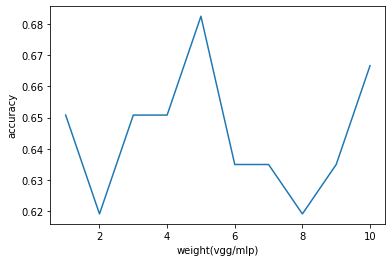

In [8]:
import matplotlib.pyplot as plt
list_ac = []
for we in range(1,11):
  list_ac.append(test2(model1, model2, we))
x_ac = []
for i in range(1,11):
  x_ac.append(i)
plt.plot(x_ac,list_ac)
plt.ylabel("accuracy")
plt.xlabel("weight(vgg/mlp)")
plt.show()

In [19]:
print("测试精度如下：")
test(model1, model2, 5)

测试精度如下：
测试集精度为：68%
测试集中不标准动作图片的预测精度为：56%
测试集中标准动作图片的预测精度为：76%
混淆矩阵为：
col_0  0.0  1.0
row_0          
0.0     14   11
1.0      9   29
